## Calculating result similarity

In [10]:
def get_similarity(result_count_list):
    num_results = len(result_count_list)
    # Initially filling up similarity matrix with "100"
    similarity_matrix = [[100.0 for _ in range(num_results)] for _ in range(num_results)]

    # Loop over each list, comparing it to all other lists
    for i in range(num_results):
        a_counts = result_count_list[i]
        for j in range(i + 1, num_results):
            b_counts = result_count_list[j] 

            # Get all unique keys from both result lists
            all_keys = set(a_counts.keys()).union(b_counts.keys())
            sum_min = 0
            sum_max = 0
            for key in all_keys:
                a = a_counts.get(key, 0) # "0" if key does not exist
                b = b_counts.get(key, 0) # "0" if key does not exist
                sum_min += min(a, b)
                sum_max += max(a, b)

            # Calculates the similarity and sets values inside of
            # similarity matrix:
            similarity = (sum_min / sum_max) * 100
            similarity_matrix[i][j] = similarity
            similarity_matrix[j][i] = similarity

    return similarity_matrix

## Creating noise model from CSV

### 1. Define functions for noise creation from dataframe data

#### 1.1. Readout errors

In [17]:
# Functionality-related imports
from qiskit_aer.noise import ReadoutError

# Imports for data type definitions:
from pandas import Series
from typing import Hashable
from qiskit_aer.noise import NoiseModel


def add_readout_error(
        qubit_nr: Hashable,
        attributes: Series,
        noise_model: NoiseModel
) -> None:
    """Adds readout error for specific qubit to a noise model.

    Args:
        qubit_nr (Hashable): Dataframe row index value, which aligns with
            the qubit number.
        attributes (Series): Dataframe row data (contains calibration data
            used for creating errors).
        noise_model (NoiseModel): Noise model object that created errors
            will be added to.
    """
    p1m0 = attributes["Prob meas0 prep1 "]
    p0m1 = attributes["Prob meas1 prep0 "]
    readout_error = ReadoutError([[1-p1m0, p1m0], [p0m1, 1-p0m1]])
    noise_model.add_readout_error(readout_error, [qubit_nr])

#### 1.2. Depolarizing errors

**NOTE:** CSV File format has been changed slightly. Two-qubit gate error calibration data was previously in the form of *sourceQubit_targetQubit:data*. For it to work with more recent files, the code must be adjusted.

In [18]:
# Functionality-related imports
from qiskit_aer.noise import depolarizing_error

# Imports for data type definitions:
from pandas import Series
from typing import Hashable
from qiskit_aer.noise import NoiseModel


def add_depolarizing_error(
        qubit_nr: Hashable,
        attributes: Series, 
        noise_model: NoiseModel, 
        instructions: dict
) -> None:
    """Adds depolarizing error for specific qubit to a noise model.

    A depolarizing error is added to all single-qubit and two-qubit
    gates specified in the `instructions` dictionary.

    Args:
        qubit_nr (Hashable): Dataframe row index value, which aligns with
            the qubit number.
        attributes (Series): Dataframe row data (contains calibration data
            used for creating errors).
        noise_model (NoiseModel): Noise model object that created errors
            will be added to.
        instructions (dict): Dictionary containing information about basis 
            gates (grouped as 1q and 2q) - their name used in code, name 
            of the column containing related calibration data.

    """
    # Creates single-qubit gate depolarizing errors:
    for instruction in instructions["1q"]:
        error_data = attributes[instruction["csv_name"]]
        error = depolarizing_error(param=error_data, 
                                   num_qubits=1)
        noise_model.add_quantum_error(error, 
                                      instruction["inst_name"], 
                                      qubits=[qubit_nr],
                                      warnings=False)
    
    # Creates two-qubit gate depolarizing errors:
    for instruction in instructions["2q"]:
        # Not all rows contain two-qubit calibration data because of directional
        # connectivity constraints.
        if isinstance(attributes[instruction["csv_name"]], str):
            error_data_list = attributes[instruction["csv_name"]].split(";")
            for error_data in error_data_list:
                q_pair, q_pair_error = error_data.split(":")
                q1, q2 = q_pair.split("_")
                error = depolarizing_error(param=float(q_pair_error), 
                                           num_qubits=2)
                noise_model.add_quantum_error(error, 
                                              instruction["inst_name"], 
                                              qubits=[int(q1), int(q2)],
                                              warnings=False)

#### 1.3. Thermal relaxation errors

**Important things to note:**
- Some `T2` values are larger than `2*T1`, which conflicts with the following rule: `T2 <= 2*T1`. The method for picking appropriate `T2` value was based on provided examples in the following *Qiskit Aer* documentation page: https://qiskit.github.io/qiskit-aer/tutorials/3_building_noise_models.html (Tutorial for building noise models).
- Obtainable CSV calibration data files have slightly changed since launching these experiments. Single-qubit gate times were not included before, however, two-qubit gate times were (column `Gate time (ns)`). This explains the additional argument `gate_times`.
- It can be seen that `1e-6` and `1e-9` are used as multipliers for time values. This is so that the value units are treated as intended (micro and nano respectively). *Qiskit Aer* also demonstrates that the difference can work with any base unit, as long as they maintain relative differences. For example, nano being the base, and micro being multiplied by `1e3`. The version used in this solution was based on personal preference.

In [19]:
# Functionality-related imports
from qiskit_aer.noise import thermal_relaxation_error

# Imports for data type definitions:
from pandas import Series, DataFrame
from typing import Hashable
from qiskit_aer.noise import NoiseModel


def add_thermal_error(
        qubit_nr: Hashable,
        attributes: Series, 
        noise_model: NoiseModel,
        instructions: dict,
        gate_times: dict,
        df: DataFrame
) -> None:
    """Adds thermal relaxation error for specific qubit to a noise model.

    A thermal relaxation error is added to all single-qubit and two-qubit
    gates specified in the `instructions` dictionary, as well as a few
    other ones: rz, measure, reset.

    Args:
        qubit_nr (Hashable): Dataframe row index value, which aligns with
            the qubit number.
        attributes (Series): Dataframe row data (contains calibration data
            used for creating errors).
        noise_model (NoiseModel): Noise model object that created errors
            will be added to.
        instructions (dict): Dictionary containing information about basis 
            gates (grouped as 1q and 2q) - their name used in code, name 
            of the column containing related calibration data.
        gate_times (dict): Dictionary containing single-qubit gate and reset
            operation times (`1q` and `reset`).
        df (DataFrame): The same Pandas dataframe being looped through. It
            is required to look up `T1` and `T2` times for target qubits of
            two-qubit gates.
    """
    t1 = attributes["T1 (us)"] * 1e-6
    t2 = min(attributes["T2 (us)"]* 1e-6, 2*t1)

    thermal_err_1q = thermal_relaxation_error(t1, t2, gate_times["1q"])
     # Adds created thermal relaxation error to all single-qubit gates.
    for instruction in instructions["1q"]:
        # Rz gate has a different gate time.
        if instruction["inst_name"] == "rz": continue
        noise_model.add_quantum_error(thermal_err_1q, 
                                      instruction["inst_name"], 
                                      qubits=[qubit_nr],
                                      warnings=False)

    # Not all rows contain two-qubit calibration data because of directional
    # connectivity constraints.
    if isinstance(attributes["Gate time (ns)"], str):
        two_qubit_gate_times = attributes["Gate time (ns)"].split(";")
        for data in two_qubit_gate_times:
            q_pair, time = data.split(":")
            q1, q2 = q_pair.split("_")
            # Adding thermal relaxation error to two-qubit gates requires
            # T1 and T2 times for the target qubit.
            t1_q2 = df.loc[int(q2)]["T1 (us)"] *1e-6
            t2_q2 = min(df.loc[int(q2)]["T2 (us)"] *1e-6, 2*t1_q2)
            thermal_err_2q = thermal_relaxation_error(t1, t2, float(time) * 1e-9).expand(
                thermal_relaxation_error(t1_q2, t2_q2, float(time) * 1e-9))
            # Adds created thermal relaxation error to all two-qubit gates.
            for instruction in instructions["2q"]:
                noise_model.add_quantum_error(thermal_err_2q, 
                                              instruction["inst_name"], 
                                              qubits=[int(q1), int(q2)],
                                              warnings=False)

    # Creates and adds thermal relaxation for `RZ` gate
    thermal_err_rz = thermal_relaxation_error(t1, t2, 0)
    noise_model.add_quantum_error(thermal_err_rz, 
                                  instructions="rz", 
                                  qubits=[qubit_nr],
                                  warnings=False)

    # Creates and adds thermal relaxation for `measure` instruction
    readout_length = attributes["Readout length (ns)"] * 1e-9
    thermal_err_readout = thermal_relaxation_error(t1, t2, readout_length)
    noise_model.add_quantum_error(thermal_err_readout, 
                                  instructions="measure", 
                                  qubits=[qubit_nr],
                                  warnings=False)

    # Creates and adds thermal relaxation for `reset` instruction
    thermal_err_reset = thermal_relaxation_error(t1, t2, gate_times["reset"])
    noise_model.add_quantum_error(thermal_err_reset, 
                                  instructions="reset", 
                                  qubits=[qubit_nr],
                                  warnings=False)

### 2. Define instructions and gate times

In [20]:
instructions = {
    "1q": [
        {"csv_name": "ID error ", 
         "inst_name": "id"},
        {"csv_name": "Z-axis rotation (rz) error ", 
         "inst_name": "rz"},
        {"csv_name": "Pauli-X error ", 
         "inst_name": "x"},
        {"csv_name": "√x (sx) error ", 
         "inst_name": "sx"}
    ],
    "2q": [
        {"csv_name": "ECR error ", 
         "inst_name": "ecr"}
    ]
}

gate_times = {
    "1q" : 60 * 1e-9,
    "reset" : 1300 * 1e-9
}

basis_gate_list = ["delay", "measure", "reset",
                   "ecr", "id", "rz", "sx", "x"]

### 3. Read CSV

In [21]:
# Functionality-related imports
import pandas as pd

# Turns CSV data to a Pandas dataframe
df = pd.read_csv("assets/csv_files/ibm_brisbane_calibrations_2025-04-30T23_05_30Z.csv")

### 4. Create noise model

In [22]:
# Functionality-related imports
from qiskit_aer.noise import NoiseModel

noise_model = NoiseModel(basis_gate_list)

for qubit_nr, attributes in df.iterrows():
    add_readout_error(qubit_nr, attributes, noise_model)
    add_depolarizing_error(qubit_nr, attributes, noise_model, instructions)
    add_thermal_error(qubit_nr, attributes, noise_model, instructions, gate_times, df)

## Obtaining coupling map

**NOTE:** QPU coupling maps are directional!

In [27]:
# Imports for data type definitions:
from pandas import DataFrame

# Functionality-related imports
from qiskit.transpiler.coupling import CouplingMap


def get_coupling_map(
        dataframe: DataFrame
) -> CouplingMap:
    """Obtains, creates and returns CouplingMap.

    The list is created based on two-qubit data columns (in this case
    two-qubit gate time), as they contain both the target and source
    qubit.

    Args:
        datafrane (DataFrame): Pandas dataframe containing QPU calibration
            data from CSV file. 

    Returns:
        CouplingMap: Map of directionally connected qubits based on
            provided dataframe calibration data.
    """
    coupling_list = []
    for _, attributes in dataframe.iterrows():
    # Not all rows contain two-qubit calibration data because of directional
    # connectivity constraints.
        if isinstance(attributes["Gate time (ns)"], str):
            two_qubit_gate_times = attributes["Gate time (ns)"].split(";")
            for data in two_qubit_gate_times:
                q_pair, _ = data.split(":")
                q1, q2 = q_pair.split("_")
                coupling_list.append([int(q1), int(q2)])

    return CouplingMap(couplinglist=coupling_list)

## Creating simulator instance

In [28]:
from qiskit_aer import AerSimulator

coupling_map = get_coupling_map(dataframe=df)

simulator = AerSimulator(coupling_map=coupling_map, 
                         noise_model=noise_model)

## Random circuit generation

In [8]:
from qiskit import qpy
from qiskit.circuit.random import random_circuit

# Generating new quantum circuit:
rqc = random_circuit(num_qubits=5, 
                     depth=10, 
                     measure=True)
# Writing generated circuit to file:
with open("assets/circuits/5q-111.qpy", "wb") as file:
    qpy.dump(rqc, file)

## Generated circuits

In [1]:
from qiskit import qpy

# 5 qubit circuit with depth 10
with open("assets/circuits/5q-1.qpy", "rb") as handle:
    rqc1 = qpy.load(handle)
# 5 qubit circuit with depth 20
with open("assets/circuits/5q-2.qpy", "rb") as handle:
    rqc2 = qpy.load(handle)
# 5 qubit circuit with depth 30
with open("assets/circuits/5q-3.qpy", "rb") as handle:
    rqc3 = qpy.load(handle)

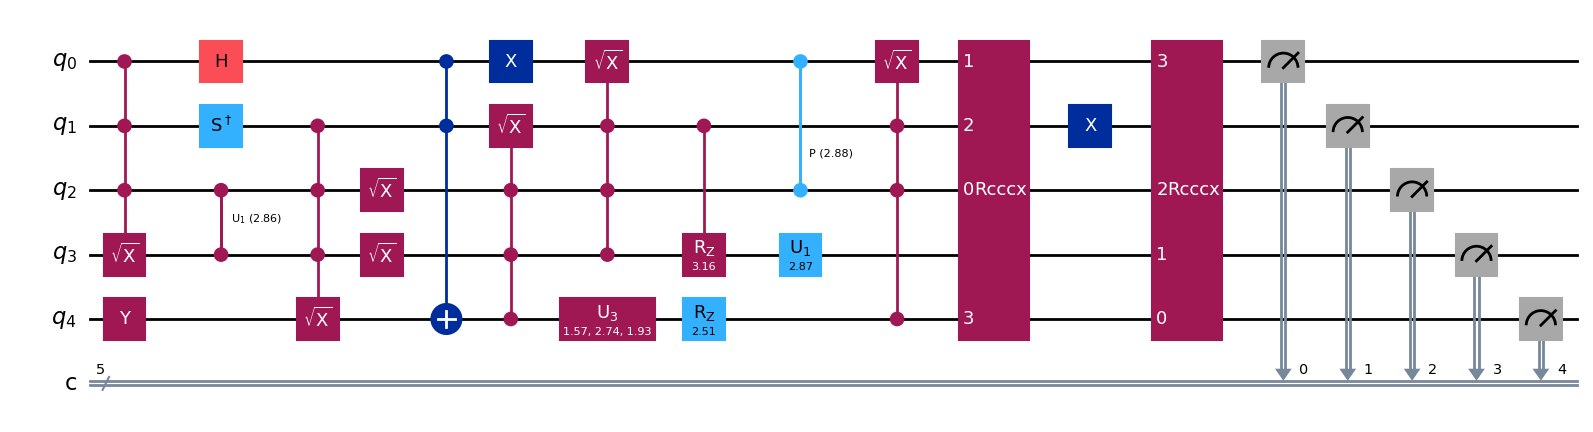

In [2]:
rqc1[0].draw(output='mpl')

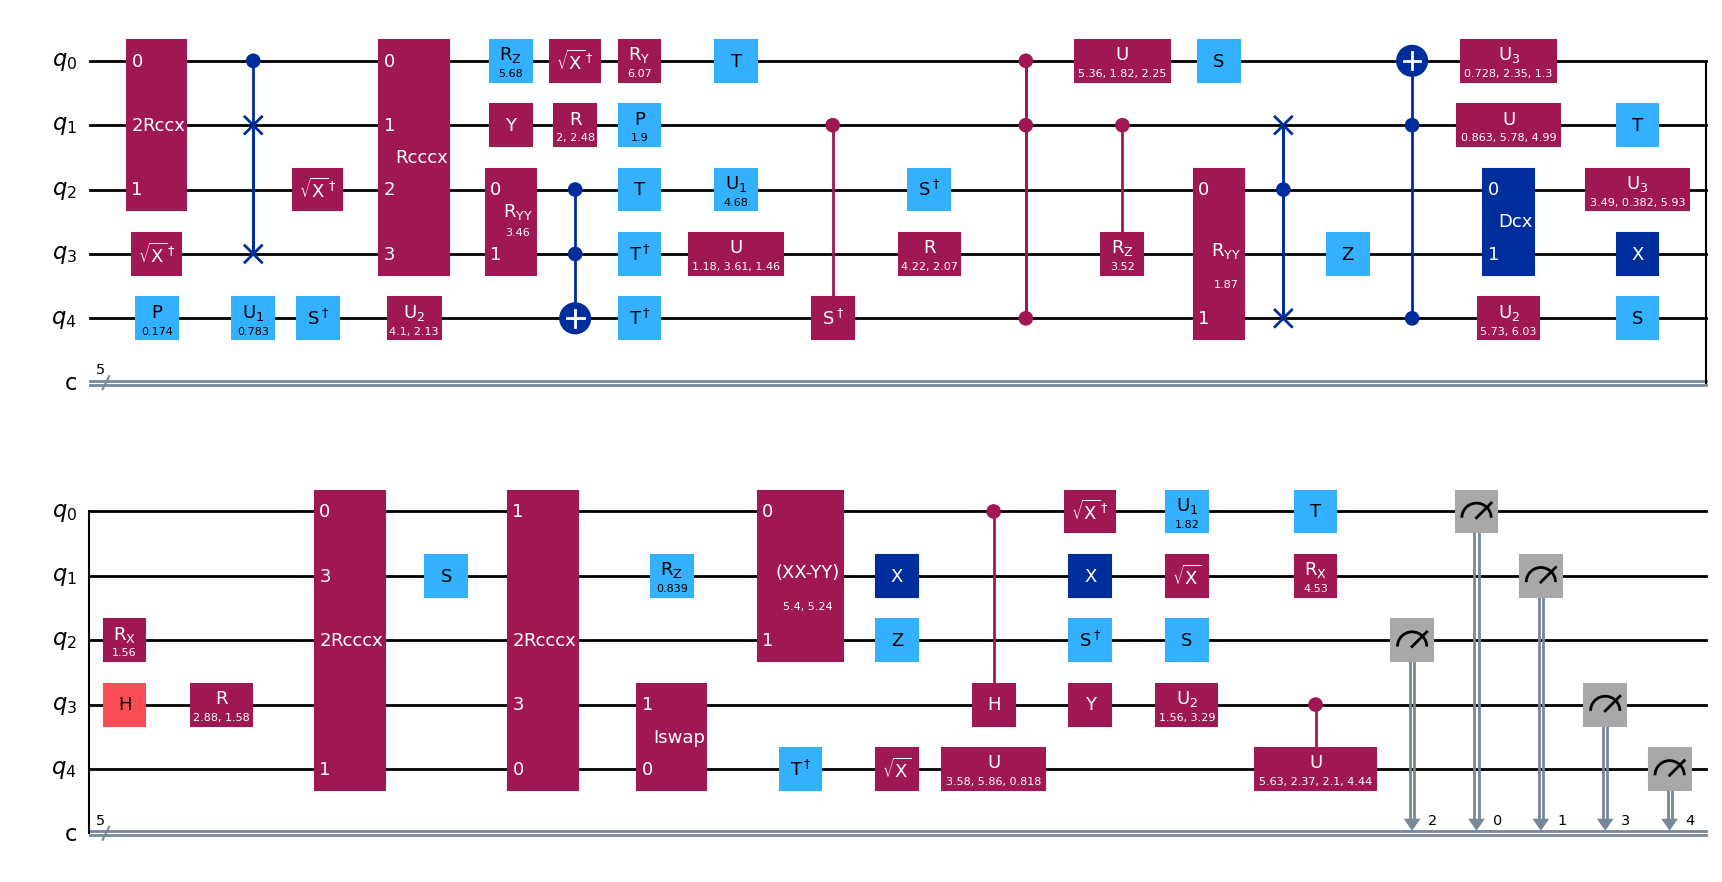

In [3]:
rqc2[0].draw(output='mpl')

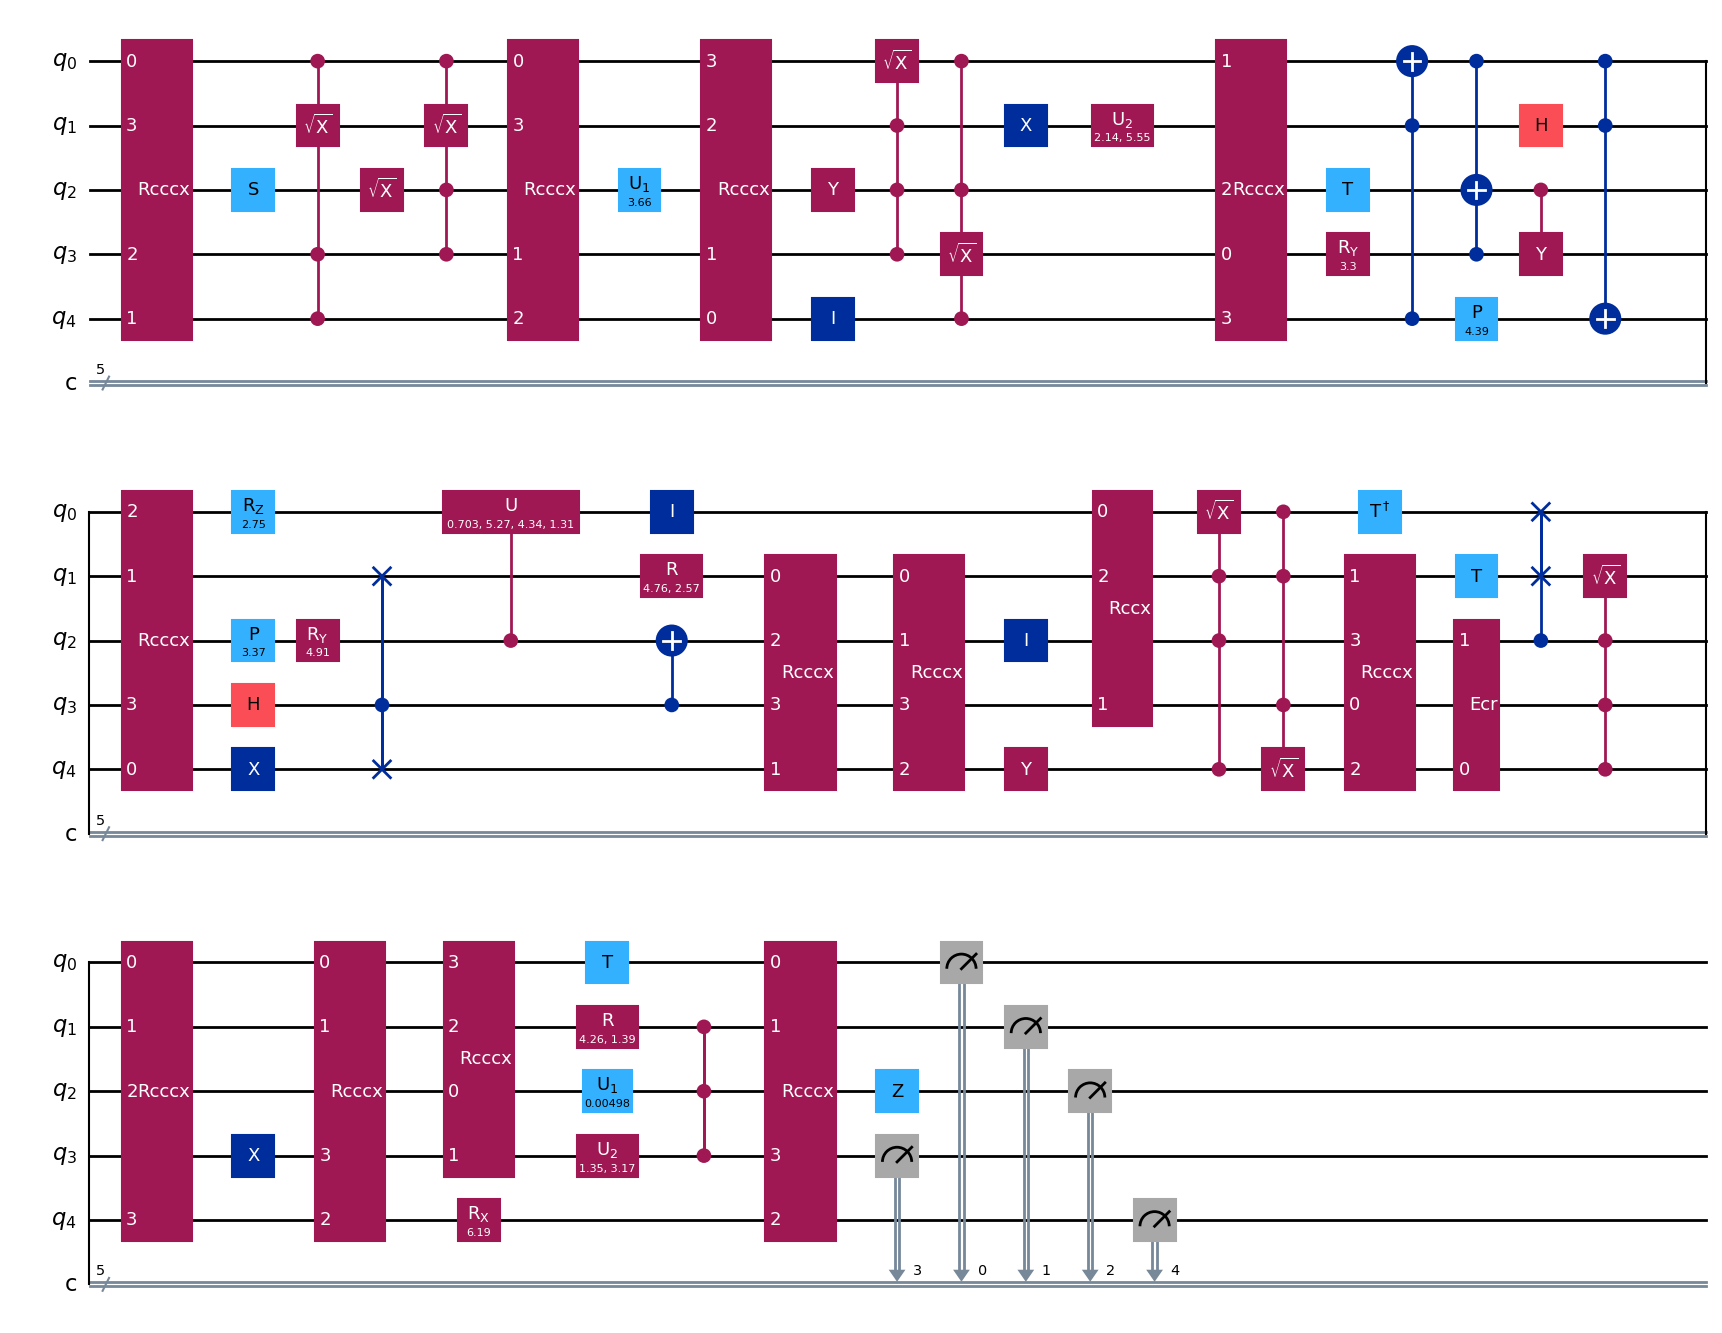

In [4]:
rqc3[0].draw(output='mpl')